# Bees production 

### Setup

In [158]:
import numpy as np
import pandas as pd 
import seaborn as sns
import utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(utils)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

honey_production_df, apistox_df, inspections_on_weather_dict = utils.load_bees_datasets()
honey_production_df_copy = honey_production_df.copy()


 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


## Part 1: Honey production 

In [109]:
honey_production_df = honey_production_df_copy.copy()

n_states = honey_production_df.state.nunique()
utils.EDA(honey_production_df, head = n_states) #44 states
honey_production_df.drop(columns=["Unnamed: 0"], inplace=True)
for state in honey_production_df.state.unique():
    state_production = honey_production_df[honey_production_df.state == state]
    #filtering for the states that have data for all the 27 years from 1995 to 2021
    if len(state_production) < 27:
        honey_production_df.drop(state_production.index, inplace=True)


honey_production_df_copy = honey_production_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


##-------------- DESCRIBE --------------------------##
        Unnamed: 0  colonies_number  yield_per_colony    production  \
count  1115.00000      1115.000000       1115.000000  1.115000e+03   
mean    557.00000     62438

### Production Analysis 

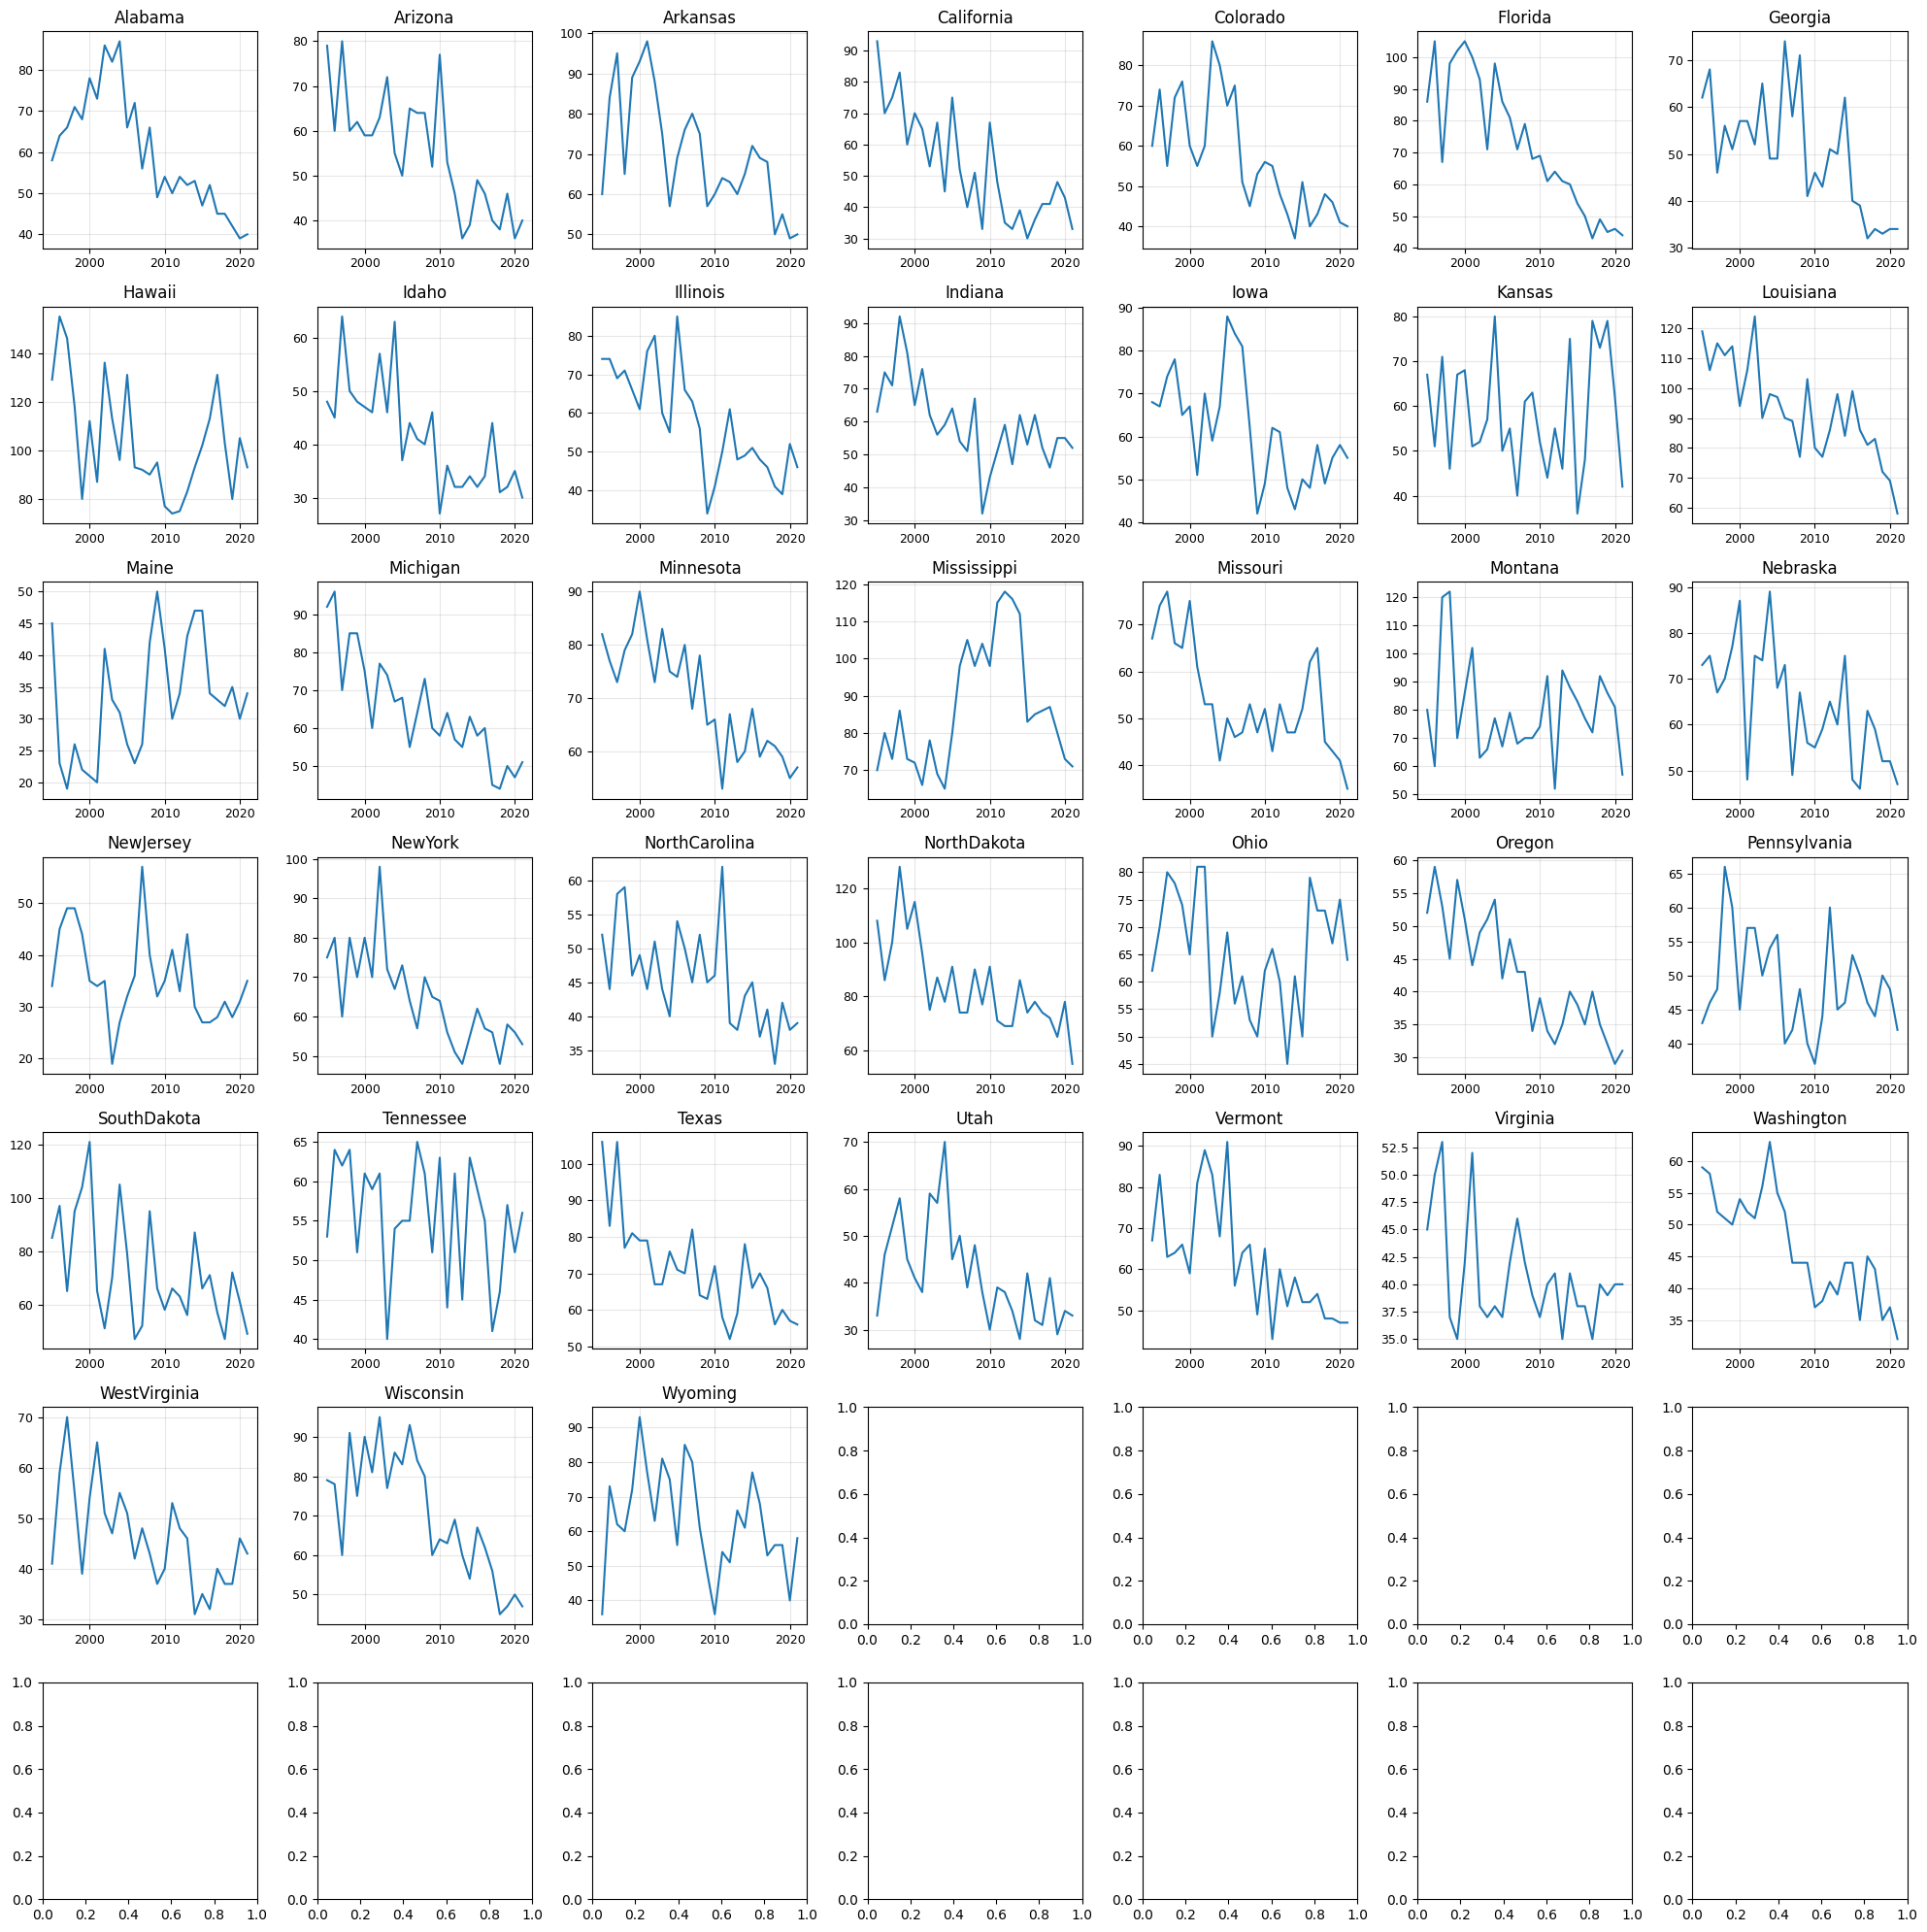

In [ ]:
utils.plot_all(honey_production_df, "state", "year", "yield_per_colony")

### Production Trend Prediction

0.8217742830203364


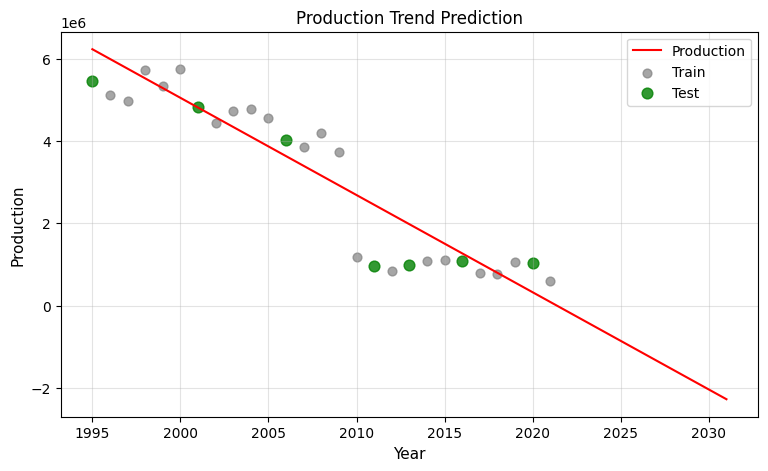

In [50]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Production")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

### Price analysis

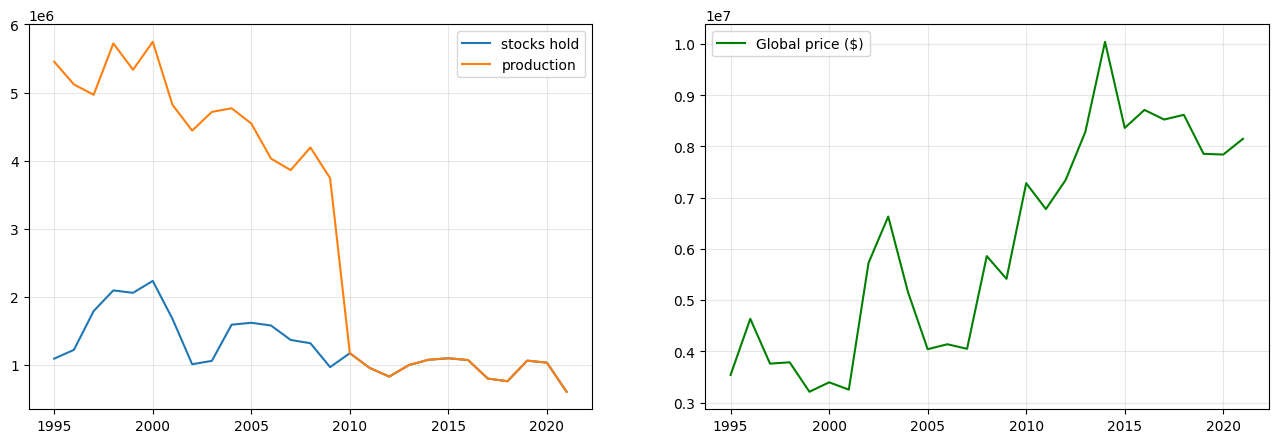

In [51]:
figure = plt.figure(figsize=(16,5))
plot1 = figure.add_subplot(1,2,1)
plot2 = figure.add_subplot(1,2,2)
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["stocks"].mean(), label = "stocks hold")
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["production"].mean(), label = "production")
plot2.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["value_of_production"].mean(), label = "Global price ($)", color = "green")
plot1.legend()
plot2.legend()
plot1.grid(alpha = 0.3)
plot2.grid(alpha = 0.3)

### Price trend Prediction 

0.7937643373061338


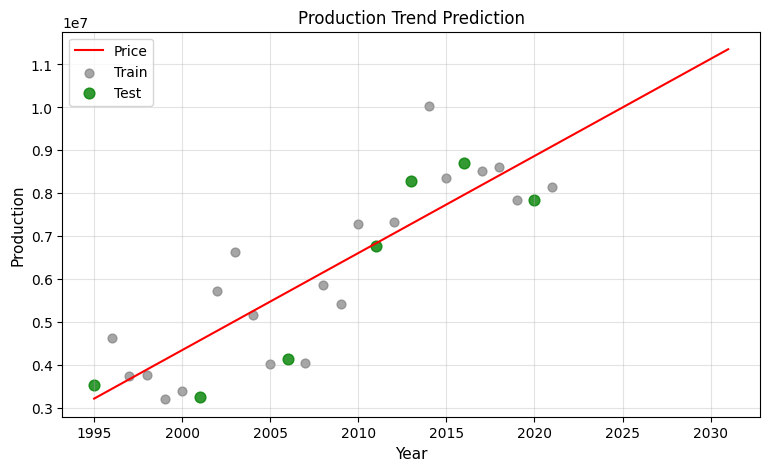

In [52]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["value_of_production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Price")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

## Part 2: Apistox 

In [48]:
utils.EDA(apistox_df, head = 7)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


##-------------- DESCRIBE --------------------------##
        

## Part 3: Weather Effects on Bees Health


"HCC_Inspections": contains the inspections result, together with with the percentage of requirements met. An hive is health iff all requirements are set to 1.

    - Brood: all phases of a brood are present (egg, larvae, pupae)
    - Bees: there are enough bees in the hive to manage it and defend it
    - Queen: the queen is alive, young and can reproduce
    - Food: there's enough food and source of found outside
    - Stressors: there are no stressors 
    - Space: the space is safe, clean and not in detriment 

"Hourly_Weather": contains an analysis of the weather during the recorded hour.
Important notes:

    - Degrees are in Fahrenheit
    - Wind_Gust represents the peak of speed during a recorded interval

In [159]:
table = inspections_on_weather_dict["HCC_Inspections"]
utils.EDA(table)

table

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2404 entries, 0 to 2403
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InpsectionID  2404 non-null   int64  
 1   HiveID        2404 non-null   int64  
 2   InsptDate     2402 non-null   object 
 3   Brood         2388 non-null   float64
 4   Bees          2388 non-null   float64
 5   Queen         2388 non-null   float64
 6   Food          2400 non-null   float64
 7   Stressors     2389 non-null   float64
 8   Space         2388 non-null   float64
 9   Percent_Met   2404 non-null   int64  
 10  Healthy       2404 non-null   object 
dtypes: float64(6), int64(3), object(2)
memory usage: 206.7+ KB


##-------------- DESCRIBE --------------------------##
        InpsectionID       HiveID        Brood         Bees        Queen  \
count   2404.000000  2404.000000  2388.000000  2388.000000  2388.000000   
mean  

,InpsectionID,HiveID,InsptDate,Brood,Bees,Queen,Food,Stressors,Space,Percent_Met,Healthy
0,1,1,2016-06-15,1.0,1.0,1.0,1.0,0.0,1.0,83,No
1,2,1,2016-07-22,1.0,1.0,1.0,1.0,0.0,1.0,83,No
2,3,1,2016-08-01,1.0,1.0,1.0,1.0,1.0,1.0,100,Yes
3,4,1,2016-08-08,1.0,1.0,1.0,1.0,1.0,1.0,100,Yes
4,5,1,2016-08-15,1.0,1.0,1.0,1.0,0.0,1.0,83,No
...,...,...,...,...,...,...,...,...,...,...,...
2399,2400,188,2018-09-24,1.0,1.0,0.0,1.0,1.0,1.0,83,No
2400,2401,188,2018-10-01,1.0,1.0,0.0,1.0,1.0,1.0,83,No
2401,2402,188,2018-10-01,1.0,1.0,0.0,1.0,1.0,1.0,83,No
2402,2403,188,2018-10-08,1.0,1.0,0.0,1.0,1.0,1.0,83,No


In [171]:
apiary_part = inspections_on_weather_dict["Apiary_Information"].merge(inspections_on_weather_dict["Hive_Information"]).merge(inspections_on_weather_dict["HCC_Inspections"])
apiary_part.rename(columns={"InsptDate": "Date", }, inplace=True)
apiary_part.Date = pd.to_datetime(apiary_part.Date, format="%Y-%m-%d")

weather_part = inspections_on_weather_dict["Weather_Stations"].merge(inspections_on_weather_dict["Hourly_Weather"]).merge(inspections_on_weather_dict["Weather_Observations"])
weather_part.rename(columns={"Station_City": "City", }, inplace=True)
weather_part.Date = pd.to_datetime(weather_part.Date, format="%m/%d/%Y")

inspections_on_weather_df = weather_part.merge(apiary_part, on="Date")
inspections_on_weather_df.dropna(axis= 0, inplace=True)
inspections_on_weather_df.columns = inspections_on_weather_df.columns.map(str.upper)
inspections_on_weather_df.rename(columns = {"INPSECTIONID" : "INSPECTIONID"}, inplace=True)
inspections_on_weather_df.HEALTHY = inspections_on_weather_df.HEALTHY.map(lambda x : 1 if x == "Yes" else 0)

inspections_on_weather_df.STATE = inspections_on_weather_df.STATE.map(lambda x: "NORTHCAROLINA" if x == "NC" else "UTAH")
inspections_on_weather_df[["TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP"]] = inspections_on_weather_df[["TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP"]].apply(lambda x: pd.to_numeric(x.str.strip()) if x.dtype == "object" else pd.to_numeric(x))

inspections_on_weather_df_copy = inspections_on_weather_df.copy()
inspections_on_weather_df.columns


Index(['STATIONID', 'CITY_X', 'STATION', 'WEATHERID', 'OBSID', 'TEMPERATURE',
       'HUMIDITY', 'DEW_POINT', 'WIND_DIRECTION', 'WIND_SPEED', 'WIND_GUST',
       'PRESSURE', 'PRECIP', 'CONDITION', 'SUNRISE', 'SUNSET',
       'DAYLIGHT_HOURS', 'DATE', 'OBS_TIME', 'OBS_HOUR', 'APIARYID', 'APIARY',
       'CITY_Y', 'STATE', 'HIVEID', 'HIVE_TAG', 'INSPECTIONID', 'BROOD',
       'BEES', 'QUEEN', 'FOOD', 'STRESSORS', 'SPACE', 'PERCENT_MET',
       'HEALTHY'],
      dtype='object')

### Apiatory part analysis

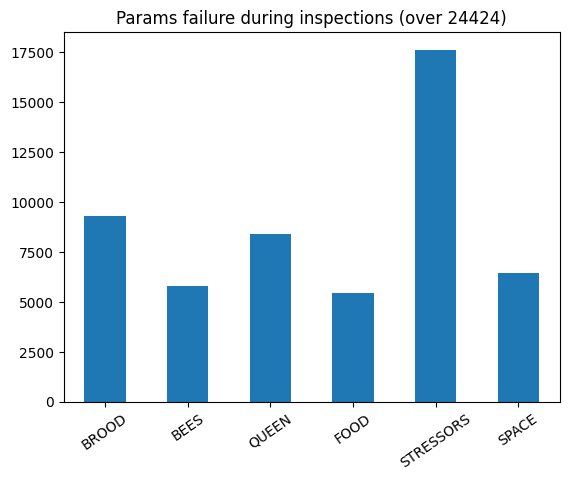

In [176]:
inspections_on_weather_df = inspections_on_weather_df_copy
failed_rows = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0].shape[0]
failed_params = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0][["BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE"]].sum()
failed_params = failed_rows - failed_params 
plot = failed_params.plot(kind = "bar", 
                   title = f"Params failure during inspections (over {inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0].shape[0]})")
plot.tick_params(axis = "x", rotation = 35)

In [189]:
inspections_on_weather_df.groupby("STATE")[[ "BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE", "HEALTHY"]].mean()

,BROOD,BEES,QUEEN,FOOD,STRESSORS,SPACE,HEALTHY
STATE,,,,,,,
NORTHCAROLINA,0.713310,0.814032,0.746993,0.824501,0.437545,0.792737,0.237922
UTAH,0.833333,0.984127,0.793651,0.984127,0.888889,0.984127,0.674603


### Weather elements impact Classification

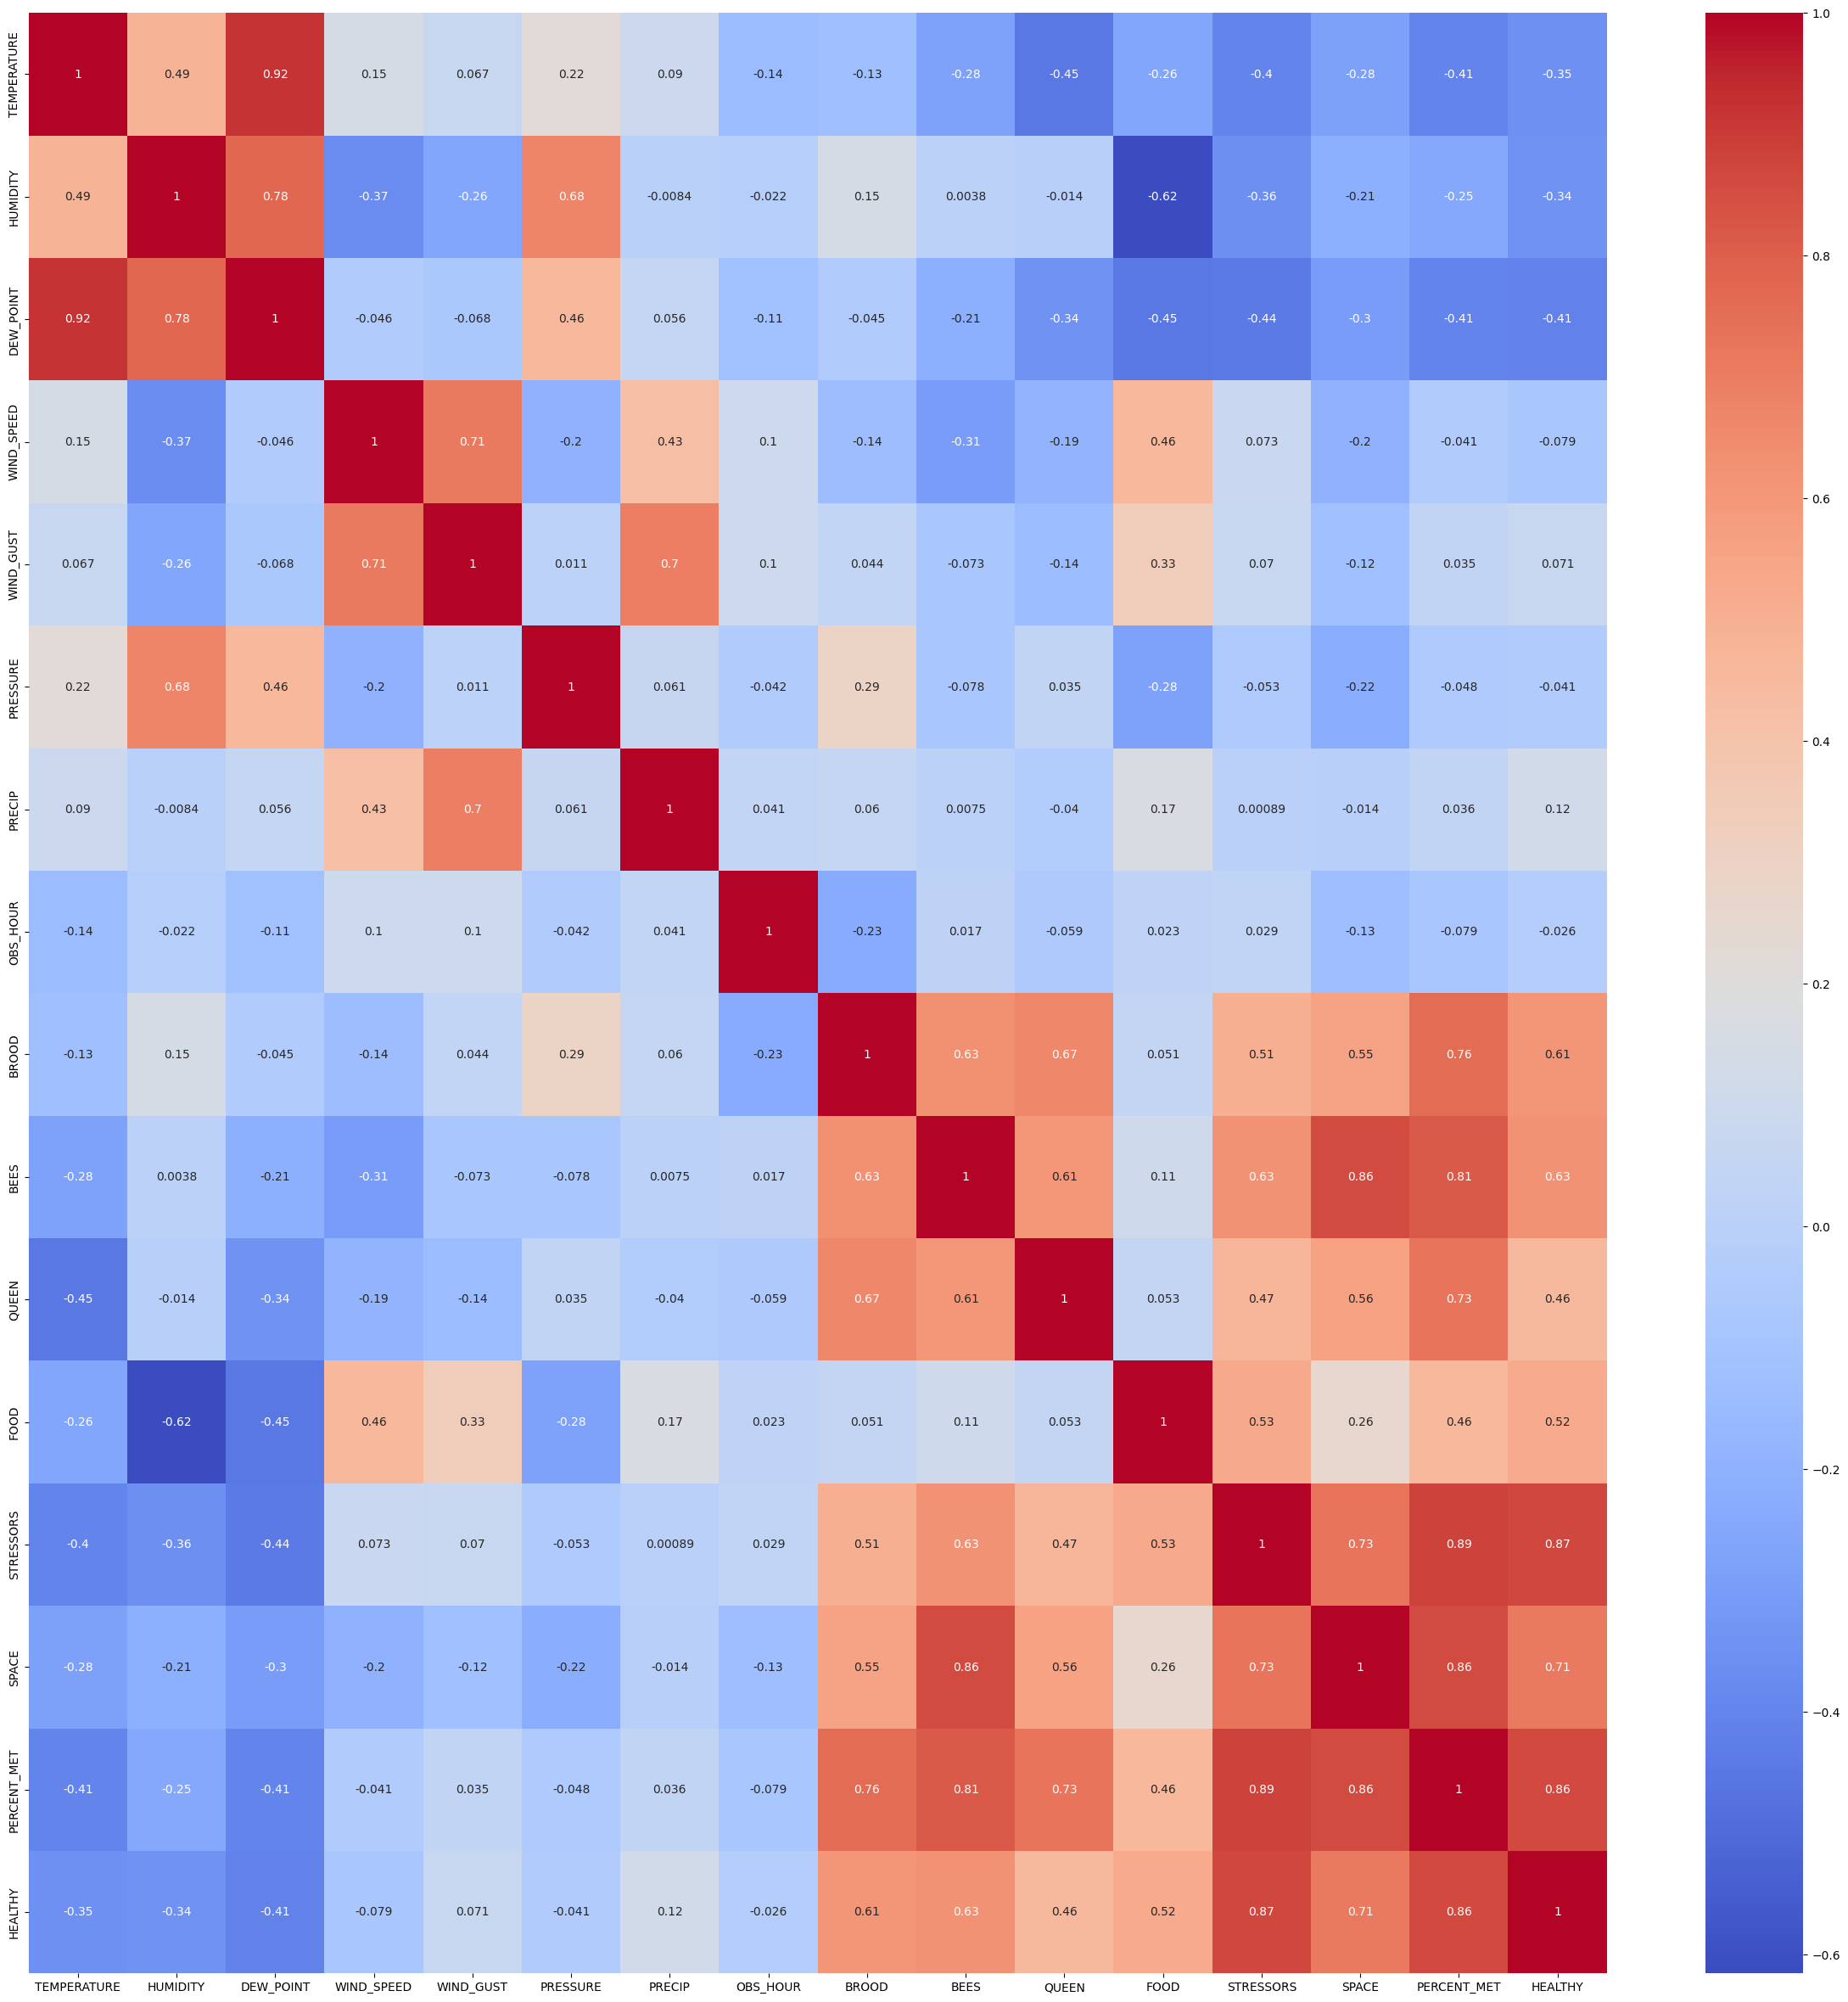

In [175]:
inspections_on_weather_df = inspections_on_weather_df_copy

inspections_on_weather_df["YEAR"] = inspections_on_weather_df.DATE.dt.year
inspections_on_weather_df["MONTH"] = inspections_on_weather_df.DATE.dt.month

# target_col = "PERCENT_MET"
#inspections_on_weather_df = inspections_on_weather_df.groupby(["STATE", "YEAR", "MONTH"])[["TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP",target_col]]
# result, _ = utils.random_forest(inspections_on_weather_df.drop([target_col], axis = 1),inspections_on_weather_df[target_col], 700)
# result
inspections_on_weather_df = inspections_on_weather_df.drop(["STATIONID", "WEATHERID", "OBSID", "APIARYID", "HIVEID", "INSPECTIONID"],axis = 1)
inspections_on_weather_df = inspections_on_weather_df.groupby(["STATE", "YEAR", "MONTH"])

inspections_on_weather_df = inspections_on_weather_df.mean(numeric_only=True).round(2)*1000

plt.figure(figsize=(30,30))
sns.heatmap(inspections_on_weather_df.corr(), annot=True, cmap="coolwarm")
plt.show()